# Demand Forecasting with Time-Aware Machine Learning

## Project overview

This project develops a machine-learning model to forecast product demand from historical retail data. The goal is not only to obtain accurate predictions, but to evaluate the model in a way that reflects a real forecasting setting: training on past observations and measuring performance on a later, unseen period.

The final workflow uses **XGBoost**, calendar and historical-demand features, chronological validation, and a naive forecasting benchmark.

### Key results

On the future holdout period (**September 2, 2023–January 30, 2024**), the tuned XGBoost model achieved:

| Metric | XGBoost | Naive baseline |
|---|---:|---:|
| RMSE | **12.386** | 55.459 |
| MAE | **8.598** | 43.369 |
| R² | **0.921** | -0.580 |

XGBoost reduced RMSE by **77.7%** relative to the previous-demand baseline. These results are reported on a chronologically held-out test period rather than a random split.

### What this notebook demonstrates

- Time-aware train/test splitting and cross-validation
- Leakage-conscious lag and rolling feature engineering
- Mixed numerical/categorical preprocessing
- XGBoost hyperparameter tuning
- Benchmarking against a naive forecast
- Residual, feature-importance, and product-level error analysis

> **Scope:** Results describe predictive performance on this dataset. Feature importance and exploratory relationships should not be interpreted as causal effects.


## 1. Environment and libraries

The analysis uses pandas and NumPy for data manipulation, scikit-learn for preprocessing, validation, and metrics, and XGBoost for gradient-boosted regression.


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)
from xgboost import XGBRegressor

pd.set_option("display.max_columns", None)
RANDOM_STATE = 42

## 2. Data loading and quality checks

The dataset contains daily retail observations with product, store, pricing, inventory, promotion, weather, seasonality, and demand information. Dates are converted to a proper datetime type and the data are ordered chronologically before any time-dependent features are created.

For reproducibility in Google Colab, update `DATA_PATH` if the CSV is stored elsewhere.


In [ ]:
DATA_PATH = "/content/demand_forecasting.csv"

df = pd.read_csv(DATA_PATH)
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Date", "Product ID"]).reset_index(drop=True)

print(f"Rows: {len(df):,}")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
display(df.head())

Rows: 76,000
Date range: 2022-01-01 to 2024-01-30


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S002,P0001,Groceries,South,102,102,331,90.89,0,Cloudy,0,81.87,Winter,0,118
2,2022-01-01,S003,P0001,Toys,East,182,109,193,16.85,10,Sunny,0,15.48,Winter,0,112
3,2022-01-01,S004,P0001,Groceries,West,215,85,287,10.47,0,Snowy,0,11.51,Winter,0,81
4,2022-01-01,S005,P0001,Groceries,North,182,75,198,11.46,5,Snowy,0,9.92,Winter,0,84


In [ ]:
display(df.dtypes.to_frame("dtype"))
print("Missing values:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

,dtype
Date,datetime64[ns]
Store ID,object
Product ID,object
Category,object
Region,object
Inventory Level,int64
Units Sold,int64
Units Ordered,int64
Price,float64
Discount,int64


Missing values: 0
Duplicate rows: 0


## 3. Time-aware feature engineering

Forecasting models can benefit from both calendar context and information about recent demand. This section creates:

- **Calendar features:** year, month, day, weekday, week of year, quarter, and weekend indicator
- **Pricing feature:** discounted price
- **Lag features:** demand from 1, 7, 14, and 30 prior observations
- **Rolling features:** historical mean and standard deviation over 7-, 14-, and 30-observation windows

All rolling statistics are calculated after `shift(1)`. This ensures that the demand value being predicted is not included in its own predictors and helps prevent target leakage.


In [ ]:
# Calendar features
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["DayOfWeek"] = df["Date"].dt.dayofweek
df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)
df["Quarter"] = df["Date"].dt.quarter
df["IsWeekend"] = (df["DayOfWeek"] >= 5).astype(int)

# Existing domain feature
df["Discounted Price"] = df["Price"] * (1 - df["Discount"] / 100)

# Historical demand features, calculated independently for each product.
g = df.groupby("Product ID", group_keys=False)["Demand"]

for lag in [1, 7, 14, 30]:
    df[f"Demand_Lag_{lag}"] = g.shift(lag)

for window in [7, 14, 30]:
    df[f"Demand_Rolling_Mean_{window}"] = (
        df.groupby("Product ID")["Demand"]
          .transform(lambda s: s.shift(1).rolling(window=window, min_periods=window).mean())
    )
    df[f"Demand_Rolling_Std_{window}"] = (
        df.groupby("Product ID")["Demand"]
          .transform(lambda s: s.shift(1).rolling(window=window, min_periods=window).std())
    )

lag_cols = [c for c in df.columns if c.startswith("Demand_Lag_") or c.startswith("Demand_Rolling_")]
print(df[lag_cols].isna().sum())

Demand_Lag_1               20
Demand_Lag_7              140
Demand_Lag_14             280
Demand_Lag_30             600
Demand_Rolling_Mean_7     140
Demand_Rolling_Std_7      140
Demand_Rolling_Mean_14    280
Demand_Rolling_Std_14     280
Demand_Rolling_Mean_30    600
Demand_Rolling_Std_30     600
dtype: int64


### Initial-history rows

The longest historical feature requires 30 prior observations for each product. As a result, the earliest rows for each product necessarily contain missing lag/rolling values. These rows are excluded from modeling because the required history does not yet exist; this is an expected consequence of feature construction rather than missing source data.


In [ ]:
model_df = df.dropna(subset=lag_cols).copy()
model_df = model_df.sort_values(["Date", "Product ID"]).reset_index(drop=True)

print(f"Rows available for modeling: {len(model_df):,}")
print(f"Modeling date range: {model_df['Date'].min().date()} to {model_df['Date'].max().date()}")

Rows available for modeling: 75,400
Modeling date range: 2022-01-07 to 2024-01-30


## 4. Exploratory time-series analysis

Before modeling, aggregate demand is inspected over time and by product category. The purpose of this section is to identify broad temporal patterns and provide context for the forecasting problem. The visualizations are descriptive and are not used to make causal claims.


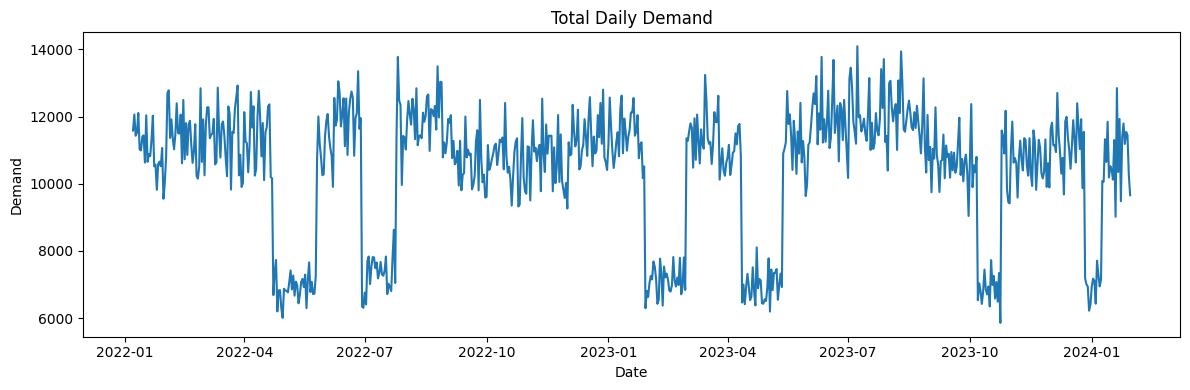

In [ ]:
daily_demand = model_df.groupby("Date", as_index=False)["Demand"].sum()

plt.figure(figsize=(12, 4))
plt.plot(daily_demand["Date"], daily_demand["Demand"])
plt.title("Total Daily Demand")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.tight_layout()
plt.show()

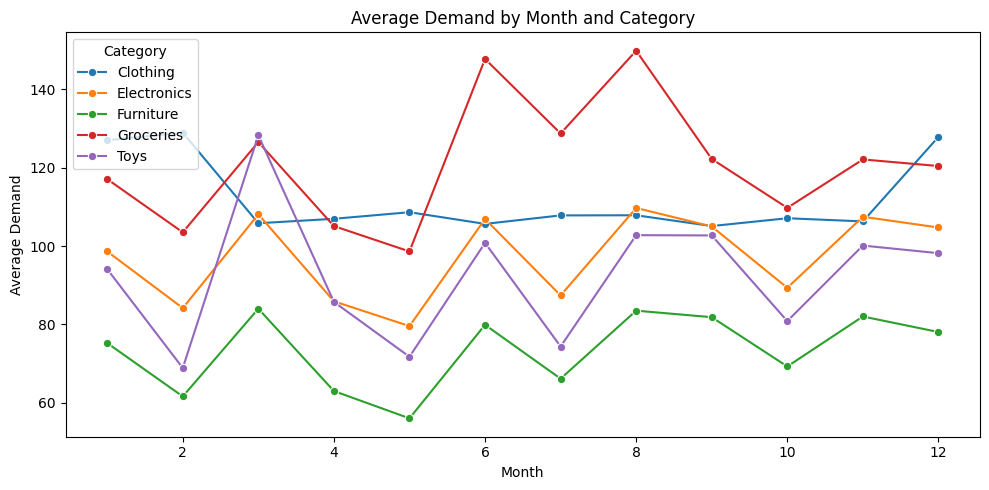

In [ ]:
monthly_category = (
    model_df.groupby(["Month", "Category"], as_index=False)["Demand"].mean()
)

plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly_category, x="Month", y="Demand", hue="Category", marker="o")
plt.title("Average Demand by Month and Category")
plt.xlabel("Month")
plt.ylabel("Average Demand")
plt.tight_layout()
plt.show()

## 5. Modeling features and target

`Demand` is the prediction target. Product ID and other nominal variables are retained as categorical predictors, while engineered calendar, pricing, and historical-demand variables are included as numerical predictors.

The raw `Date` field is intentionally excluded from XGBoost. It is used to enforce temporal ordering and to visualize predictions, while calendar information is represented through engineered features.


In [ ]:
target = "Demand"

candidate_features = [
    "Product ID", "Category", "Region", "Weather Condition", "Seasonality",
    "Price", "Discount", "Discounted Price", "Inventory Level", "Promotion",
    "Competitor Pricing", "Epidemic",
    "Year", "Month", "Day", "DayOfWeek", "WeekOfYear", "Quarter", "IsWeekend",
    "Demand_Lag_1", "Demand_Lag_7", "Demand_Lag_14", "Demand_Lag_30",
    "Demand_Rolling_Mean_7", "Demand_Rolling_Std_7",
    "Demand_Rolling_Mean_14", "Demand_Rolling_Std_14",
    "Demand_Rolling_Mean_30", "Demand_Rolling_Std_30"
]

# Makes the notebook tolerant of small schema differences.
features = [c for c in candidate_features if c in model_df.columns]
missing_candidates = [c for c in candidate_features if c not in model_df.columns]
if missing_candidates:
    print("Not present in the CSV and therefore skipped:", missing_candidates)

X = model_df[features].copy()
y = model_df[target].copy()
dates = model_df["Date"].copy()

print(f"Using {len(features)} predictors")

Using 29 predictors


## 6. Future holdout design

A random train/test split would allow observations from later dates to appear in training while earlier dates appear in testing. That setup does not closely represent the intended forecasting use case.

Instead, the final **20% of unique dates** are reserved as an untouched holdout period. All observations before the cutoff are used for model development, and all observations on or after the cutoff are used only for final evaluation.

For this dataset, the resulting periods are:

- **Training:** January 7, 2022–September 1, 2023
- **Test:** September 2, 2023–January 30, 2024


In [ ]:
unique_dates = np.array(sorted(model_df["Date"].unique()))
split_date = pd.Timestamp(unique_dates[int(len(unique_dates) * 0.80)])

train_mask = model_df["Date"] < split_date
test_mask = model_df["Date"] >= split_date

X_train, X_test = X.loc[train_mask].copy(), X.loc[test_mask].copy()
y_train, y_test = y.loc[train_mask].copy(), y.loc[test_mask].copy()
dates_train, dates_test = dates.loc[train_mask].copy(), dates.loc[test_mask].copy()

print("Training period:", dates_train.min().date(), "to", dates_train.max().date())
print("Testing period: ", dates_test.min().date(), "to", dates_test.max().date())
print("Training rows:", len(X_train))
print("Testing rows: ", len(X_test))

Training period: 2022-01-07 to 2023-09-01
Testing period:  2023-09-02 to 2024-01-30
Training rows: 60300
Testing rows:  15100


## 7. Preprocessing pipeline

Nominal categorical variables are one-hot encoded so that arbitrary numeric ranks are not imposed on categories. Numerical predictors pass through unchanged. Preprocessing and XGBoost are combined in a scikit-learn `Pipeline`, which keeps transformations consistent during cross-validation and final prediction.


In [ ]:
categorical_features = [
    c for c in ["Product ID", "Category", "Region", "Weather Condition", "Seasonality"]
    if c in features
]
numeric_features = [c for c in features if c not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True), categorical_features),
        ("num", "passthrough", numeric_features),
    ],
    remainder="drop"
)

print("Categorical:", categorical_features)
print("Numeric:", numeric_features)

Categorical: ['Product ID', 'Category', 'Region', 'Weather Condition', 'Seasonality']
Numeric: ['Price', 'Discount', 'Discounted Price', 'Inventory Level', 'Promotion', 'Competitor Pricing', 'Epidemic', 'Year', 'Month', 'Day', 'DayOfWeek', 'WeekOfYear', 'Quarter', 'IsWeekend', 'Demand_Lag_1', 'Demand_Lag_7', 'Demand_Lag_14', 'Demand_Lag_30', 'Demand_Rolling_Mean_7', 'Demand_Rolling_Std_7', 'Demand_Rolling_Mean_14', 'Demand_Rolling_Std_14', 'Demand_Rolling_Mean_30', 'Demand_Rolling_Std_30']


## 8. Model selection with time-series cross-validation

The training period is used to tune an `XGBRegressor` with `RandomizedSearchCV`. Rather than ordinary shuffled cross-validation, `TimeSeriesSplit` preserves temporal ordering across validation folds.

The search evaluates 25 hyperparameter combinations across five time-series folds using RMSE as the selection criterion. The test period remains untouched during this process.

The selected configuration produced a cross-validation RMSE of approximately **19.27**.


In [ ]:
xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=RANDOM_STATE,
    n_jobs=1,
    tree_method="hist"
)

pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", xgb)
])

param_distributions = {
    "model__n_estimators": [200, 300, 500, 700],
    "model__max_depth": [3, 4, 6, 8],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__subsample": [0.7, 0.8, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 1.0],
    "model__min_child_weight": [1, 3, 5]
}

tscv = TimeSeriesSplit(n_splits=5)

random_search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_distributions,
    n_iter=25,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)
print("Best CV RMSE:", -random_search.best_score_)
print("Best parameters:")
display(random_search.best_params_)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best CV RMSE: 19.265786552429198
Best parameters:


{'model__subsample': 1.0,
 'model__n_estimators': 500,
 'model__min_child_weight': 1,
 'model__max_depth': 8,
 'model__learning_rate': 0.1,
 'model__colsample_bytree': 0.7}

## 9. Final holdout performance

After model selection, the best pipeline is evaluated once on the future holdout period. Three complementary metrics are reported:

- **RMSE:** penalizes larger forecast errors more heavily
- **MAE:** average absolute forecast error in demand units
- **R²:** proportion of holdout variance explained relative to a constant-mean reference

The model achieved **RMSE = 12.386**, **MAE = 8.598**, and **R² = 0.921** on the September 2023–January 2024 holdout period.


In [ ]:
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

model_rmse = root_mean_squared_error(y_test, y_pred)
model_mae = mean_absolute_error(y_test, y_pred)
model_r2 = r2_score(y_test, y_pred)

metrics = pd.DataFrame({
    "Metric": ["RMSE", "MAE", "R²"],
    "XGBoost": [model_rmse, model_mae, model_r2]
})
display(metrics)

,Metric,XGBoost
0,RMSE,12.386186
1,MAE,8.598473
2,R²,0.921172


## 10. Benchmark against a naive forecast

Model accuracy is more informative when compared with a simple forecasting rule. The benchmark used here predicts each observation using that product's most recently observed demand (`Demand_Lag_1`).

The naive forecast produced **RMSE = 55.459** and **MAE = 43.369**, compared with **12.386** and **8.598** for XGBoost. This corresponds to a **77.7% reduction in RMSE** for the machine-learning model on the holdout period.

The baseline is intentionally simple; stronger operational benchmarks could be added in future work.


In [ ]:
baseline_pred = X_test["Demand_Lag_1"].to_numpy()

baseline_rmse = root_mean_squared_error(y_test, baseline_pred)
baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_r2 = r2_score(y_test, baseline_pred)

comparison = pd.DataFrame({
    "Model": ["Naive: previous demand", "XGBoost"],
    "RMSE": [baseline_rmse, model_rmse],
    "MAE": [baseline_mae, model_mae],
    "R²": [baseline_r2, model_r2]
})
comparison["RMSE Improvement vs Baseline (%)"] = [
    0, 100 * (baseline_rmse - model_rmse) / baseline_rmse
]

display(comparison.round(3))

,Model,RMSE,MAE,R²,RMSE Improvement vs Baseline (%)
0,Naive: previous demand,55.459,43.369,-0.580,0.000
1,XGBoost,12.386,8.598,0.921,77.666


## 11. Actual vs. predicted demand over time

To make the forecast behavior easier to inspect, actual and predicted demand are aggregated across products at the daily level. This visualization complements the summary metrics by showing whether the model follows the overall level and movement of demand throughout the holdout period.


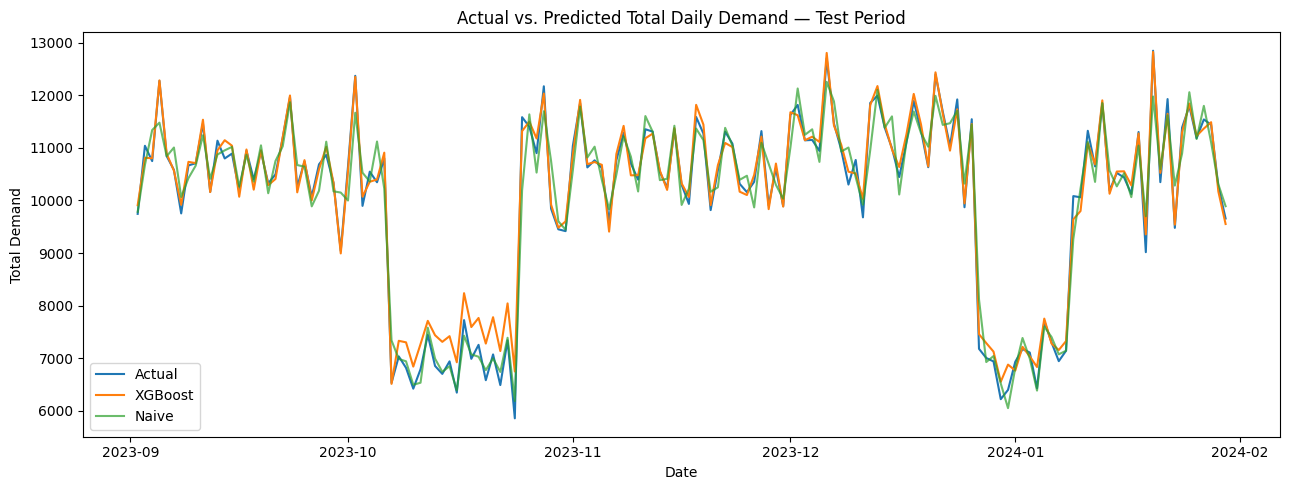

In [ ]:
results = model_df.loc[test_mask, ["Date", "Product ID", "Demand"]].copy()
results["Predicted Demand"] = y_pred
results["Naive Prediction"] = baseline_pred

daily_results = results.groupby("Date", as_index=False).agg({
    "Demand": "sum",
    "Predicted Demand": "sum",
    "Naive Prediction": "sum"
})

plt.figure(figsize=(13, 5))
plt.plot(daily_results["Date"], daily_results["Demand"], label="Actual")
plt.plot(daily_results["Date"], daily_results["Predicted Demand"], label="XGBoost")
plt.plot(daily_results["Date"], daily_results["Naive Prediction"], label="Naive", alpha=0.7)
plt.title("Actual vs. Predicted Total Daily Demand — Test Period")
plt.xlabel("Date")
plt.ylabel("Total Demand")
plt.legend()
plt.tight_layout()
plt.show()

## 12. Residual diagnostics

Residuals are defined as `actual demand - predicted demand`. A useful forecasting model should not show strong systematic structure in its errors.

The mean residual on the holdout set is approximately **-0.83 demand units**, indicating a small average tendency toward overprediction. The residual plot should still be inspected for changing variance, outliers, or patterns that a single average cannot reveal.


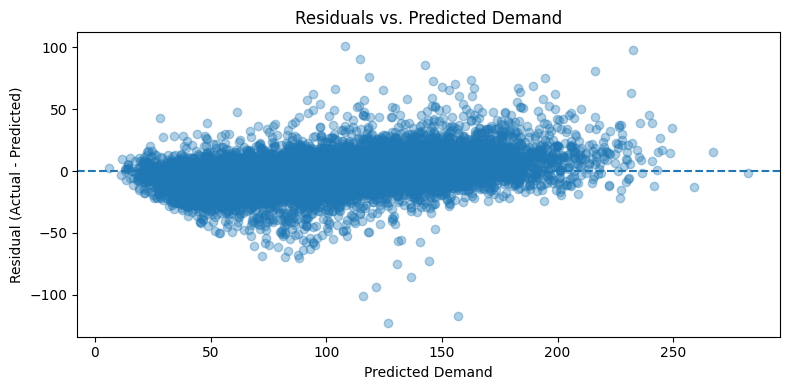

Mean residual: -0.8307072497045757


In [ ]:
results["Residual"] = results["Demand"] - results["Predicted Demand"]

plt.figure(figsize=(8, 4))
plt.scatter(results["Predicted Demand"], results["Residual"], alpha=0.35)
plt.axhline(0, linestyle="--")
plt.title("Residuals vs. Predicted Demand")
plt.xlabel("Predicted Demand")
plt.ylabel("Residual (Actual - Predicted)")
plt.tight_layout()
plt.show()

print("Mean residual:", results["Residual"].mean())

## 13. Model interpretation: feature importance

XGBoost feature importance is used to identify variables the fitted model relied on most heavily. In this run, **Promotion** had the largest reported importance, followed by **Epidemic** and several category indicators.

These values describe how the fitted model used predictors; they do **not** establish that changing a feature would cause demand to change. Correlated predictors can also distribute or concentrate importance in ways that complicate interpretation.


,Feature,Importance
41,num__Promotion,0.180959
43,num__Epidemic,0.102395
23,cat__Category_Groceries,0.095727
22,cat__Category_Furniture,0.055175
20,cat__Category_Clothing,0.042368
35,cat__Seasonality_Summer,0.028417
32,cat__Weather Condition_Sunny,0.027885
21,cat__Category_Electronics,0.020525
24,cat__Category_Toys,0.020507
5,cat__Product ID_P0006,0.016903


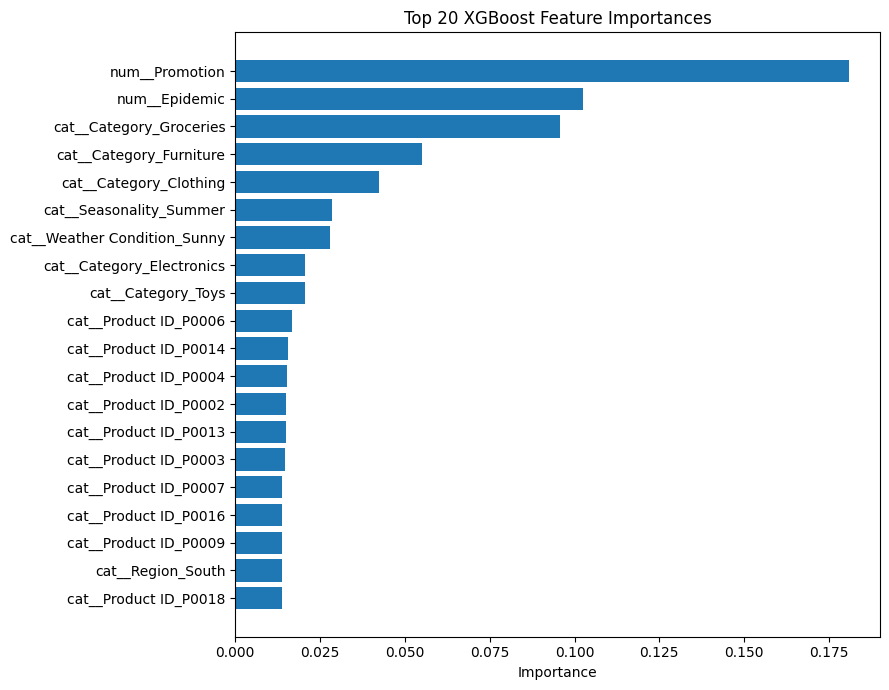

In [ ]:
fitted_preprocessor = best_model.named_steps["preprocessor"]
fitted_xgb = best_model.named_steps["model"]
feature_names = fitted_preprocessor.get_feature_names_out()

importance = (
    pd.DataFrame({
        "Feature": feature_names,
        "Importance": fitted_xgb.feature_importances_
    })
    .sort_values("Importance", ascending=False)
)

display(importance.head(20))

plt.figure(figsize=(9, 7))
top = importance.head(20).sort_values("Importance")
plt.barh(top["Feature"], top["Importance"])
plt.title("Top 20 XGBoost Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 14. Error analysis by product

Aggregate performance can hide products that are substantially easier or harder to forecast. This section calculates MAE and RMSE separately for each product in the holdout period and sorts products by RMSE.

The resulting table can be used to identify candidates for deeper investigation—for example, products with unusual volatility, sparse patterns, or relationships not captured by the current feature set.


In [ ]:
product_metrics = (
    results.groupby("Product ID")
    .apply(lambda g: pd.Series({
        "MAE": mean_absolute_error(g["Demand"], g["Predicted Demand"]),
        "RMSE": root_mean_squared_error(g["Demand"], g["Predicted Demand"]),
        "Observations": len(g)
    }), include_groups=False)
    .sort_values("RMSE", ascending=False)
)

display(product_metrics)

,MAE,RMSE,Observations
Product ID,,,
P0004,11.250925,16.710526,755.0
P0010,10.788842,16.452412,755.0
P0017,9.902885,15.068521,755.0
P0007,10.878322,14.779007,755.0
P0002,9.436791,13.774598,755.0
P0019,9.305047,13.140175,755.0
P0013,9.227183,12.972622,755.0
P0008,8.791115,12.664347,755.0
P0001,8.752459,11.806884,755.0


## 15. Conclusions

This project built and evaluated a time-aware XGBoost demand-forecasting pipeline on **76,000 retail observations** spanning January 2022 through January 2024. After creating historical features, **75,400 observations** remained available for modeling.

The final model was trained on observations through September 1, 2023 and evaluated on a future holdout period from September 2, 2023 through January 30, 2024. It achieved:

- **RMSE:** 12.386
- **MAE:** 8.598
- **R²:** 0.921
- **RMSE improvement vs. naive previous-demand baseline:** 77.7%

The comparison with the naive benchmark provides evidence that, on this dataset and holdout period, the model captures useful predictive structure beyond simply carrying the previous demand value forward.

### Interpretation and limitations

The model's feature-importance results suggest that promotion status, the epidemic indicator, product category, seasonality, weather, product identity, and other engineered predictors contributed to its predictions. These importances are predictive rather than causal.

Several limitations remain. The evaluation uses one final historical holdout window, so performance may differ in other time periods or under structural changes. The naive baseline is deliberately simple and could be supplemented with seasonal-naive or moving-average benchmarks. In addition, the current model assumes that predictor values needed at forecast time—such as pricing, promotions, inventory, weather, and competitor pricing—are known or can themselves be forecast.

### Potential next steps

Future iterations could add stronger seasonal baselines, walk-forward backtesting across multiple holdout windows, prediction intervals, SHAP-based interpretation, and explicit multi-step forecasting. Deployment through Streamlit or another application layer could then be added if an interactive business-facing forecast tool is desired.


